In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from utils import *
import sys
from astropy.io import fits
import cloud_model_torch as cmt 
import matplotlib
# Default matplotlib settings
matplotlib.rcParams['image.interpolation'] = 'nearest'
%load_ext autoreload
%autoreload 2

In [2]:
# Add after imports
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
#device = "cpu"

Using device: cuda


In [3]:
# ========================================================================================================
def cloud_model(x, params=None, obs_back=None):
    # Recall that x contains also the background intensity
    if params is None:
        params = combine_parameters()
    #return cmt.model_synth(x, params)
    if obs_back is None:
        return cmt.model_synth_2clouds_givenbck(x, params, 0)
    return cmt.model_synth_2clouds_givenbck(x, params, obs_back)

In [78]:
# Here we load the data to be fit, and we also load and make the "background". 
# Let's see how will this work. 

#data_file = np.load("/mn/stornext/d20/RoCS/carlosjd/colabs/ivan/MIHI/fulldata/mihi_all_data.npz", allow_pickle=True) 
data_file = np.load("/dat/milic/MiHI_filament/mihi_all_data.npz", allow_pickle=True) 
# Here we are selecting the time instance 
t = 13
data = np.copy(data_file['data'][t])
wav = data_file['wav']
print(data.shape) 
del(data_file) 

# Load reconstruction:
data_file = np.load("/dat/milic/MiHI_filament/mihi_rvm_reconstruction_averages_skglm.npz", allow_pickle=True)
rdata = np.copy(data_file["new_fit"][t])
rextra = np.copy(data_file["new_extrafit"][t])
print(rdata.shape)
print(rextra.shape)
del(data_file)



(146, 160, 550)
(146, 160, 550)
(146, 160, 550)


In [80]:

bdata = rdata - rextra # Ivan's suggestion
# bdata = data - rextra
print(bdata.shape)

# If neeed reshape so that there is an extra first dimension for time:
data = data.reshape((1, *data.shape))
rdata = rdata.reshape((1, *rdata.shape))
rextra = rextra.reshape((1, *rextra.shape))
bdata = bdata.reshape((1, *bdata.shape))


(146, 160, 550)


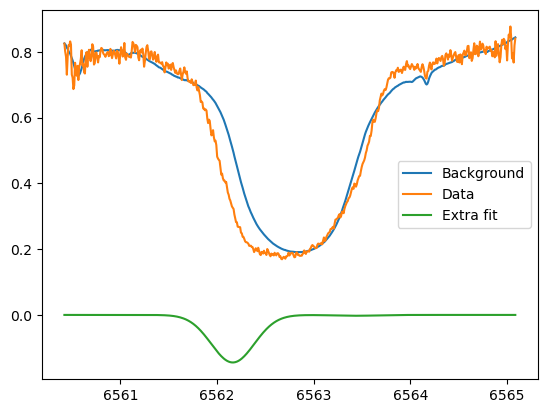

In [81]:
plt.plot(wav, bdata[0,100,100,:], label='Background')
plt.plot(wav, data[0,100,100,:], label='Data')
# plt.plot(wav, rdata[0,100,100,:], label='Reconstruction')
plt.plot(wav, rextra[0,100,100,:], label='Extra fit')
plt.legend()

In [ ]:
# # Keep memory free for now
# del(rdata)
# del(rextra)

In [ ]:
# ====================================================================
def optimization(optimizer,niterations,parameters,model, xl, obs, obs_back):
    """
    This function performs the optimization of the parameters of the model.
    """
    # Move data to GPU if not already there:
    if not isinstance(obs, torch.Tensor):
        obs = torch.from_numpy(np.array(obs.astype(np.float32)))
    if obs.device != parameters.device:
        obs = obs.to(device)
    # And then the same for obs_back
    if not isinstance(obs_back, torch.Tensor):
        obs_back = torch.from_numpy(np.array(obs_back.astype(np.float32)))
    if obs_back.device != parameters.device:
        obs_back = obs_back.to(device)

    from tqdm import trange
    t = trange(niterations, leave=True)
    for loop in t:
        
        optimizer.zero_grad()        #reset gradients
        parameters = combine_parameters()
        syn = cloud_model(xl, parameters, obs_back)
        syn = syn.reshape(obs.shape[0], obs.shape[1], -1)
        chi2loss = torch.mean(torch.sum((obs - syn)**2.0))
        
        reguloss = chi2loss*0.0
        
        # Strongly regularize the source function gradients. We want it super smooth. 
        reguloss += 1e3*regu2(parameters, 0, obs)
        reguloss += 1e3*regu2(parameters, 5, obs) 

        # regularize tau slightly
        reguloss += 1e-1*regu2(parameters, 1, obs)
        reguloss += 1e-1*regu2(parameters, 6, obs)
        
        # LOS velocity - should be regularized too, gently
        reguloss += 1e-2*regu2(parameters, 2, obs)
        reguloss += 1e-2*regu2(parameters, 7, obs)
        
        # And the same for the Doppler width, but even more gently
        reguloss += 1e-2*regu2(parameters, 3, obs)
        reguloss += 1e-2*regu2(parameters, 8, obs)

        # Doppler width - should also be regularized using regu-min to not have lower values than, say 8 km /s 
        reguloss += 1e8*regu_min(parameters, 3, obs.reshape(1,obs.shape[0],obs.shape[1],-1), 8.0)
        reguloss += 1e8*regu_min(parameters, 8, obs.reshape(1,obs.shape[0],obs.shape[1],-1), 8.0)
        
        # Additional regularization is that S and tau cannot be negative:
        reguloss += 1e7*regu_min(parameters, 0, obs.reshape(1,obs.shape[0],obs.shape[1],-1), 0.0)
        reguloss += 1e7*regu_min(parameters, 5, obs.reshape(1,obs.shape[0],obs.shape[1],-1), 0.0)
        reguloss += 1e7*regu_min(parameters, 1, obs.reshape(1,obs.shape[0],obs.shape[1],-1), 0.0)
        reguloss += 1e7*regu_min(parameters, 6, obs.reshape(1,obs.shape[0],obs.shape[1],-1), 0.0)
        
        # Additional regularization is that S cannot be too large
        reguloss += 1e7*regu_max(parameters, 0, obs.reshape(1,obs.shape[0],obs.shape[1],-1), 0.6)
        reguloss += 1e7*regu_max(parameters, 5, obs.reshape(1,obs.shape[0],obs.shape[1],-1), 0.6)
        
        loss = chi2loss + reguloss

        loss.backward()              #calculate gradients
        optimizer.step()             #step forward

        # Now the if below is just a debug that we use in case our exponents explode.
        if (chi2loss.item() != chi2loss.item()):  #check for NaN
            print("NaN detected. Stopping optimization.")
            
            # Maybe we should look for a specific NaN and see why it happens:
            nan_params = parameters[torch.isnan(parameters)]
            if len(nan_params) > 0:
                print("NaN values found in parameters:")
                print(nan_params)

            # Find specific nans in chisquared then and show the appropriate parameters:
            nan_syn = torch.isnan(syn)
            print ("shape of the nan_syn:", nan_syn.shape)
            if len(nan_syn):
                print("NaN values found in synthetic data:")
                print(syn[nan_syn])
                # Show the corresponding parameters
                print("Corresponding parameters:")
                print(parameters[nan_syn[:,:,0].flatten()])
                return parameters[nan_syn[:,:,0].flatten()]
            break

        t.set_postfix({'loss': loss.item(), 'chi2loss': chi2loss.item(), 'reguloss': reguloss.item()})

    # Return final parameters and synthetic image
    final_params = combine_parameters()
    final_params = final_params.reshape(obs.shape[0], obs.shape[1], -1)
    final_params = final_params.detach().cpu().numpy()
    syn = syn.detach().cpu().numpy()

    # Final cleanup
    torch.cuda.empty_cache()
    
    return final_params, syn


In [82]:
# ================================================================================================================
# Readind the data:

#data_filename = "/mn/stornext/d20/RoCS/carlosjd/colabs/ivan/MIHI/cloudinv_mihi/data/mihi_data.fits"
# data_filename = "/home/milic/data/scratch/mihi_data.fits"
#data_filename = "/home/milic/data/scratch/img_fit.210800..211599.00.00.lr0250.cube.fits"
# Now it is loaded already up there

tofit = data[0,15:-15, 15:-15,100:500]
Iqs = np.mean(tofit[:,:,-20:])
print("info::normalizing the input data to the value: ", Iqs)
tofit /= Iqs
tofit_background = bdata[0,15:-15, 15:-15,100:500]
tofit_background /= Iqs
print("info::the input observations have the shape:", tofit.shape)
print("info::the background of inferred has the shape:", tofit_background.shape)
xl = np.copy(wav[100:500])
ll0 = np.asarray([np.mean(xl)])
xl = [xl,ll0]



# Transform data into pytorch object:
tofit_pt = torch.from_numpy(np.array(tofit.astype(np.float32))).to(device)
# And the same for the background
tofit_background_pt = torch.from_numpy(np.array(tofit_background.astype(np.float32))).to(device)


info::normalizing the input data to the value:  0.75841814
info::the input observations have the shape: (116, 130, 400)
info::the background of inferred has the shape: (116, 130, 400)


In [34]:
tofit_pt.shape

torch.Size([116, 130, 400])

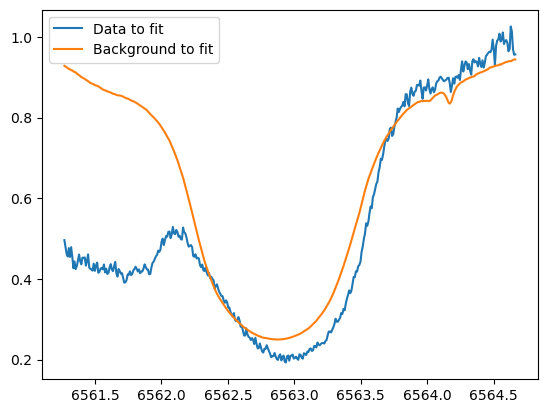

In [94]:
plt.plot(np.copy(wav[100:500]), tofit_pt[30,75,:].cpu(), label='Data to fit')
plt.plot(np.copy(wav[100:500]), tofit_background_pt[30,75,:].cpu(), label='Background to fit')
plt.legend()

In [84]:
def make_param(init_value, shape, grad=True, device='cpu'):
    param = torch.tensor(init_value, dtype=torch.float32, device=device).repeat(*shape)
    param = nn.Parameter(param, requires_grad=grad)
    return param

In [102]:
# Define independent parameter groups
n_pixels = tofit.shape[0] * tofit.shape[1]
device = tofit_pt.device


# Cloud 1 parameters (each independent)
cloud1_S = make_param(0.2, (n_pixels,), grad=True, device=device)
cloud1_tau = make_param(4.5, (n_pixels,), grad=True, device=device)
cloud1_vlos = make_param(-20.0, (n_pixels,), grad=True, device=device)
cloud1_doppler = make_param(12.0, (n_pixels,), grad=True, device=device)
cloud1_loga = make_param(-4.0, (n_pixels,), grad=False, device=device)

# Cloud 2 parameters (each independent)
cloud2_S = make_param(0.6, (n_pixels,), grad=True, device=device)
cloud2_tau = make_param(4.5, (n_pixels,), grad=True, device=device)
cloud2_vlos = make_param(20.0, (n_pixels,), grad=True, device=device)
cloud2_doppler = make_param(12.0, (n_pixels,), grad=True, device=device)
cloud2_loga = make_param(-5.0, (n_pixels,), grad=False, device=device)

# Function to combine parameters for the model
def combine_parameters():
    return torch.stack([
        cloud1_S, cloud1_tau, cloud1_vlos, cloud1_doppler, cloud1_loga,
        cloud2_S, cloud2_tau, cloud2_vlos, cloud2_doppler, cloud2_loga
    ], dim=1)

# Collect all parameters that require gradients for optimizer
params_to_optimize = []
for param in [cloud1_S, cloud1_tau, cloud1_vlos, cloud1_doppler, cloud1_loga, cloud2_S, cloud2_tau, cloud2_vlos, cloud2_doppler, cloud2_loga]:
    if param.requires_grad:
        params_to_optimize.append(param)
        
# Parameters:
print("info:: parameters:", torch.mean(combine_parameters(), axis=0))



info:: parameters: tensor([  0.2000,   4.5000, -20.0000,  12.0000,  -4.0000,   0.6000,   4.5000,
         20.0000,  12.0000,  -5.0000], device='cuda:0',
       grad_fn=<MeanBackward1>)


In [118]:
torch.cuda.empty_cache()

# ====================================================================
# Send all the info to the optimization module inside the utils.py file:
optimizer = torch.optim.Adam(params_to_optimize, lr=5e-2)
niter = 5000
mymodel = cloud_model # Model from the above
parameters, fit_spectra = optimization(optimizer=optimizer,niterations=niter,
                                        parameters=combine_parameters(),model=mymodel,xl=xl,obs=tofit_pt, obs_back=tofit_background_pt.reshape(n_pixels,-1))

chisq = np.sum((tofit - fit_spectra)**2.0, axis=2) / 400.0
print(np.mean(chisq[0,0]))


100%|██████████| 5000/5000 [01:13<00:00, 68.49it/s, loss=2.97e+3, chi2loss=2.59e+3, reguloss=385]    


0.0005456191


In [119]:
# Average the parameters for only print:
print("info::average parameters:", np.mean(parameters, axis=(0,1)))

info::average parameters: [  0.25145692   0.84226245 -25.663898    16.658699    -4.
   0.25174573   1.034003     2.2940419   13.302218    -5.        ]


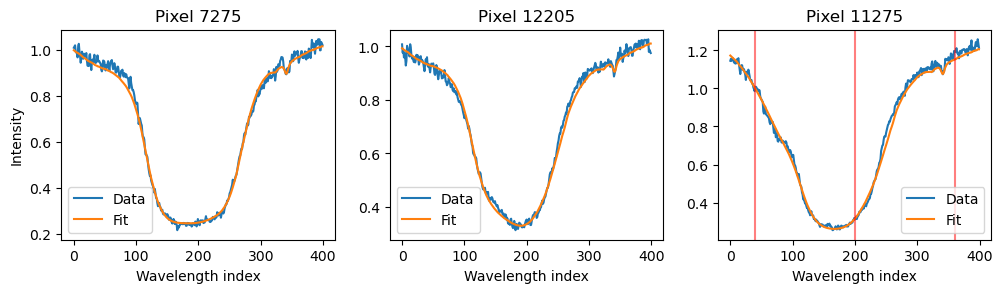

In [120]:
# Extract and compare 3 random pixels from the fit and the data:
np.random.seed(71)
idxs = np.random.randint(0, tofit.shape[0]*tofit.shape[1], size=3)
plt.figure(figsize=[12,6])
for j, idx in enumerate(idxs):
    plt.subplot(2, 3, j+1)
    plt.plot(tofit.reshape(-1, tofit_pt.shape[2])[idx], label='Data')
    plt.plot(fit_spectra.reshape(-1, fit_spectra.shape[2])[idx], label='Fit')
    plt.title(f"Pixel {idx}")
    plt.xlabel('Wavelength index')
    plt.legend()
    if j == 0:
        plt.ylabel('Intensity')
        
# Vertical lines at:
idxs_lambda = [int(0.1*tofit.shape[2]), int(0.5*tofit.shape[2]), int(0.9*tofit.shape[2])]
for idx_lambda in idxs_lambda:
    plt.axvline(x=idx_lambda, color='r', linestyle='-', label=f'Wavelength {idx_lambda}', alpha=0.5)

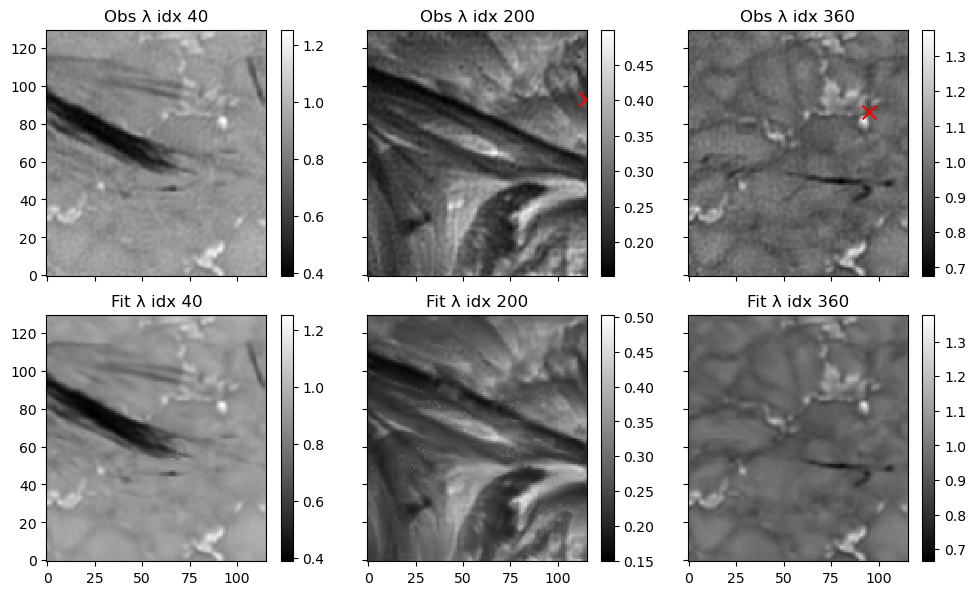

In [121]:
fig, axes = plt.subplots(2, 3, figsize=[10, 6], sharex=True, sharey=True)
for j, idx in enumerate(idxs_lambda):
    ax_obs = axes[0, j]
    im_obs = ax_obs.imshow(np.mean(tofit[:, :, idx-1:idx+2], axis=2).T, origin='lower', cmap='gray')
    ax_obs.set_title(f"Obs λ idx {idx}")
    fig.colorbar(im_obs, ax=ax_obs)
    ax_obs.scatter(idxs[j] % tofit.shape[1], idxs[j] // tofit.shape[1], color='red', marker='x', s=100)

    ax_fit = axes[1, j]
    im_fit = ax_fit.imshow(np.mean(fit_spectra[:, :, idx-1:idx+2], axis=2).T, origin='lower', cmap='gray', \
        vmin=tofit_pt[:, :, idx].min(), vmax=tofit_pt[:, :, idx].max())
    ax_fit.set_title(f"Fit λ idx {idx}")
    fig.colorbar(im_fit, ax=ax_fit)
plt.tight_layout()


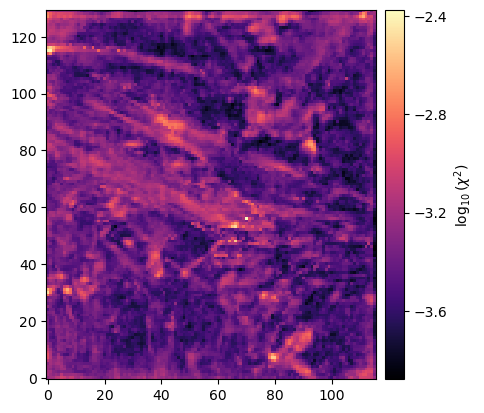

In [122]:
im = plt.imshow(np.log10(chisq).T, origin='lower', cmap='magma')
add_colorbar(im, label=r'$\log_{10}(\chi^2)$')

In [91]:
# Velocity of hydrogen atoms at prominence temperatures (5000 K at the least is:)
k_B = 1.380649e-23  # Boltzmann constant in J/K
m_H = 1.6735575e-27  # Mass of hydrogen atom in kg
T = 5000  # Temperature in Kelvin
v_thermal = np.sqrt(2 * k_B * T / m_H)  # Thermal velocity in m/s
v_thermal_kms = v_thermal / 1e3  # Convert to km/s
print(f"Thermal velocity of hydrogen atoms at {T} K: {v_thermal_kms:.2f} km/s")

Thermal velocity of hydrogen atoms at 5000 K: 9.08 km/s


<Figure size 1000x400 with 0 Axes>

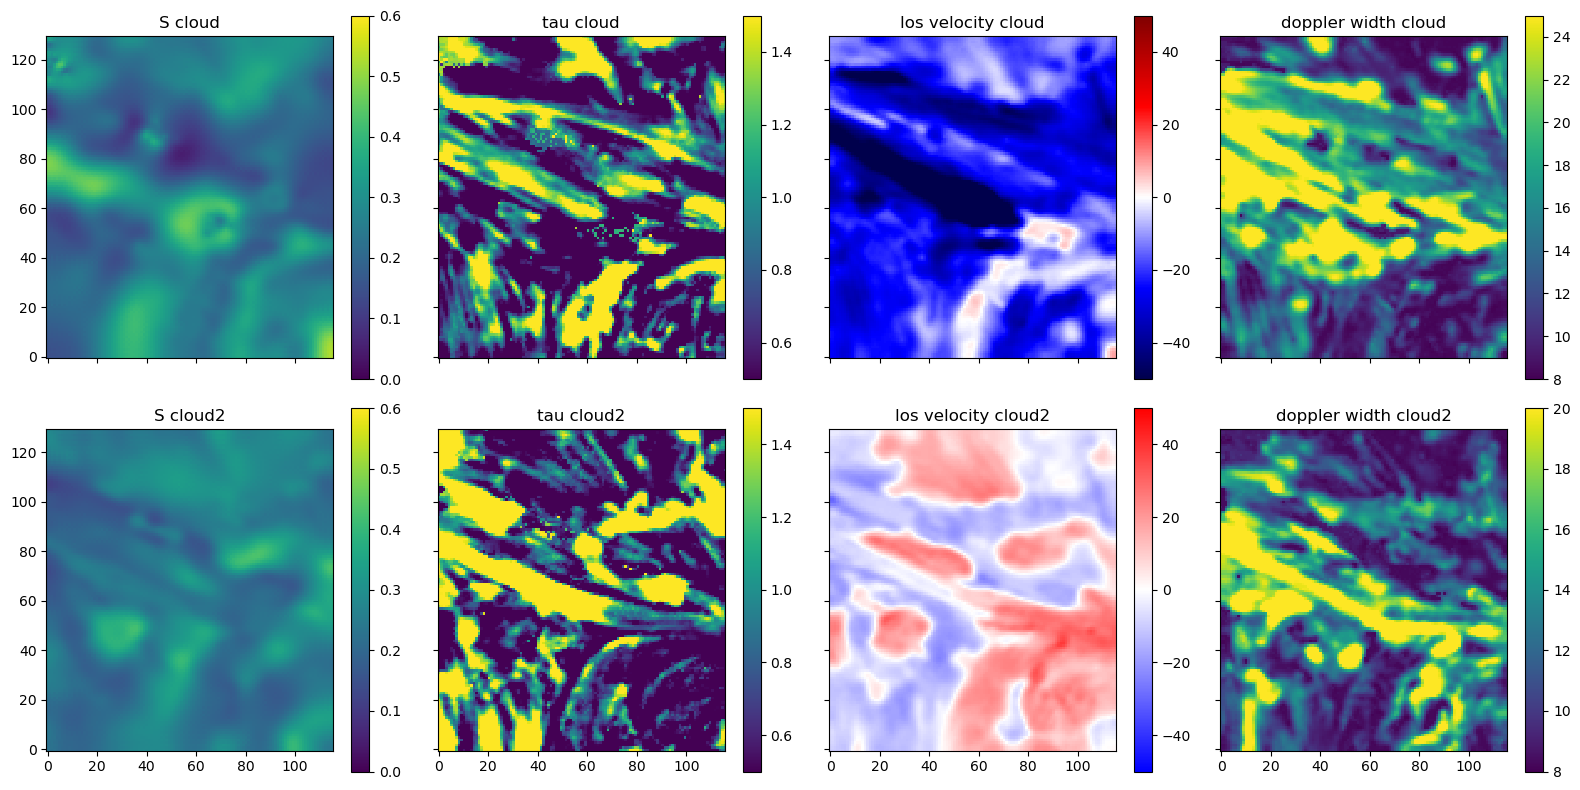

In [129]:
labels = ['S cloud', 'tau cloud', 'los velocity cloud', 'doppler width cloud',\
          'S cloud2', 'tau cloud2', 'los velocity cloud2',\
          'doppler width cloud2']

to_plot = np.array([0,1,2,3,5,6,7,8])
vmin_limit  = np.array([0.0, 0.5, -50.0, 8.0, 0.0, 0.5, -50.0, 8.0])
vmaX_limit  = np.array([0.6, 1.5, 50.0, 25.0, 0.6, 1.5, 50.0, 20.0])

cmaps = ['viridis', 'viridis', 'seismic', 'viridis', 'viridis', 'viridis', 'bwr', 'viridis']

plt.figure(figsize=[10, 4])
fig, axes = plt.subplots(2, 4, figsize=[16, 8], sharex=True, sharey=True)
ax = axes.flatten()
for i in range(8):
    im = ax[i].imshow(parameters[:, :, to_plot[i]].T, origin='lower', cmap=cmaps[i], vmin=vmin_limit[i], vmax=vmaX_limit[i])
    ax[i].set_title(labels[i])
    fig.colorbar(im, ax=ax[i])
plt.tight_layout()
plt.savefig("inversion_results.png", bbox_inches='tight')


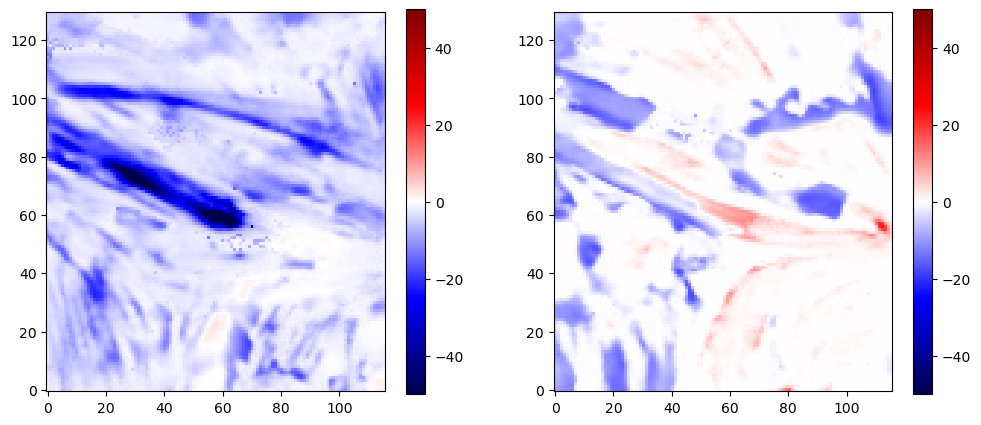

In [128]:
plt.figure(figsize=[12,5])
plt.subplot(121)
plt.imshow((parameters[:, :, 2]*0.5*(1+np.tanh(1.0*(parameters[:,:,1]-1.5)))).T, origin='lower', cmap='seismic', vmin=-50.0, vmax=50.0)
plt.colorbar()
plt.subplot(122)
plt.imshow((parameters[:, :, 7]*0.5*(1+np.tanh(2.0*(parameters[:,:,6]-1.5)))).T, origin='lower', cmap='seismic', vmin=-50.0, vmax=50.0)
plt.colorbar()

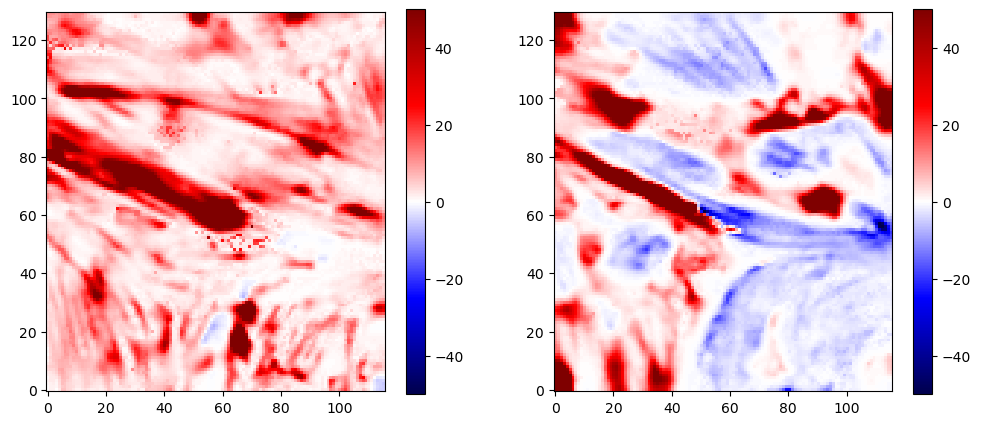

In [ ]:
plt.figure(figsize=[12,5])
plt.subplot(121)
plt.imshow((parameters[:, :, 2]*parameters[:,:,0]*(1.0 - np.exp(-parameters[:,:,1]))).T, origin='lower', cmap='seismic', vmin=-50.0, vmax=50.0)
plt.colorbar()
plt.subplot(122)
plt.imshow((parameters[:, :, 7]*parameters[:,:,5]*(1.0 - np.exp(-parameters[:,:,6]))).T, origin='lower', cmap='seismic', vmin=-50.0, vmax=50.0)
plt.colorbar()

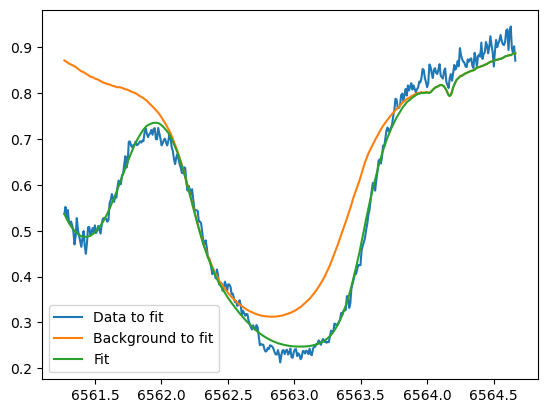

In [125]:
plt.plot(np.copy(wav[100:500]), tofit_pt[52,65,:].cpu(), label='Data to fit')
plt.plot(np.copy(wav[100:500]), tofit_background_pt[52,65,:].cpu(), label='Background to fit')
plt.plot(np.copy(wav[100:500]), fit_spectra[52,65,:], label='Fit')
plt.legend()

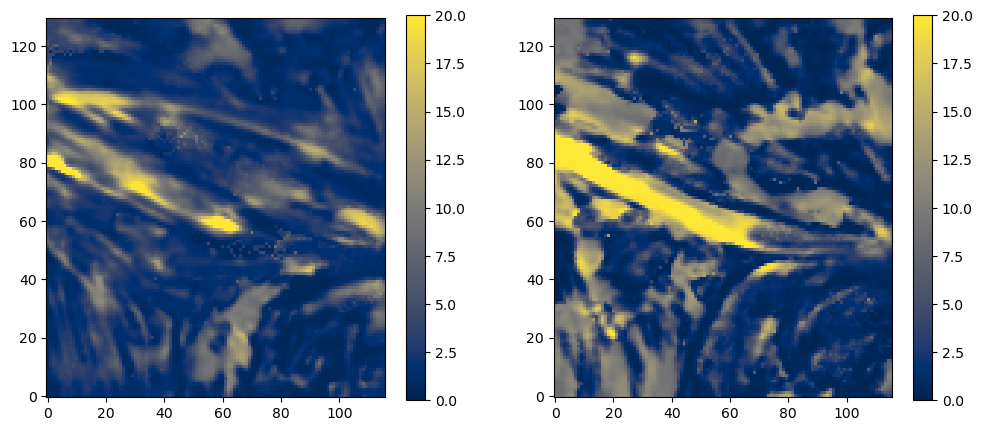

In [126]:
plt.figure(figsize=[12,5])
plt.subplot(121)
plt.imshow((parameters[:, :, 3]*0.5*(1+np.tanh(1.0*(parameters[:,:,1]-1.5)))).T, origin='lower', cmap='cividis', vmin=0, vmax=20)
plt.colorbar()
plt.subplot(122)
plt.imshow((parameters[:, :, 8]*0.5*(1+np.tanh(2.0*(parameters[:,:,6]-1.0)))).T, origin='lower', cmap='cividis', vmin=0, vmax=20)
plt.colorbar()

In [ ]:
# This was from some debug times :-)
''' Full model synthesis with two cloud layers, given background intensity.

    Args:
        x: [wavelength_array, line_center_array]
        p: parameter array with shape (n_pixels, 10)
           [S_cloud1, deltatau1, vlos_cloud1, deltav_cloud1, loga_cloud1,
            S_cloud2, deltatau2, vlos_cloud2, deltav_cloud2, loga_cloud2]

    Returns:
        Synthetic spectrum
    
    '''
    
# Try to synthesize the parameters to check what produces the NaN values: 
'''
badparams = np.array([1.9084e-01,  1.1638e+01, -2.1752e+00,  1.7381e+01, -4.0000e+00,
          6.9943e-01,  5.6913e-01,  1.1081e+01, 1.6969e-01, -5.0000e+00], dtype=np.float32)

badparams = badparams.reshape(1, -1)  # Reshape to (1, num_params)

# convert badparams to torch 
badparams_torch = torch.from_numpy(badparams).to(device)

i_inc_zeros = np.zeros(len(xl[0]))
print(i_inc_zeros.shape)
i_inc_zeros = i_inc_zeros.reshape(1, -1)  # Reshape to (1, num_wavelengths)
i_inc_zeros = torch.from_numpy(i_inc_zeros.astype(np.float32)).to(device)#

test = cmt.model_synth_2clouds_givenbck(xl, badparams_torch, i_inc_zeros)
'''